# Dutch Retail Demand Forecasting & Inventory Optimization

## Business Problem
Predict product demand for a retail chain to **reduce overstock and stockouts**.

This analysis mirrors real-world challenges at companies like Albert Heijn, Jumbo, Coolblue, and Bol.com, where demand forecasting is a core analytical capability.

**Dataset:** Corporación Favorita Grocery Sales (Kaggle Store Sales - Time Series Forecasting)

### Skills Demonstrated
- Time series analysis & decomposition
- Feature engineering (lags, rolling stats, holidays, promotions)
- Multiple forecasting models (Naive, Moving Average, Prophet, XGBoost)
- Model evaluation (RMSE, MAE, MAPE)
- Business-actionable inventory recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Data Loading & Initial Exploration

In [2]:
DATA_PATH = '../datasets/store_sales/'

train = pd.read_csv(f'{DATA_PATH}train.csv', parse_dates=['date'])
stores = pd.read_csv(f'{DATA_PATH}stores.csv')
holidays = pd.read_csv(f'{DATA_PATH}holidays_events.csv', parse_dates=['date'])
oil = pd.read_csv(f'{DATA_PATH}oil.csv', parse_dates=['date'])
transactions = pd.read_csv(f'{DATA_PATH}transactions.csv', parse_dates=['date'])

print(f'Training data: {train.shape[0]:,} rows, {train.shape[1]} columns')
print(f'Date range: {train.date.min()} to {train.date.max()}')
print(f'Stores: {train.store_nbr.nunique()}')
print(f'Product families: {train.family.nunique()}')
train.head()

Training data: 3,000,888 rows, 6 columns
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Stores: 54


Product families: 33


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
print('=== Data Quality Check ===')
print(f'\nMissing values in train:')
print(train.isnull().sum())
print(f'\nMissing oil prices: {oil.dcoilwtico.isnull().sum()} / {len(oil)} ({oil.dcoilwtico.isnull().mean()*100:.1f}%)')
print(f'\nNegative sales: {(train.sales < 0).sum()}')
print(f'Zero sales: {(train.sales == 0).sum():,} ({(train.sales == 0).mean()*100:.1f}%)')

=== Data Quality Check ===

Missing values in train:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Missing oil prices: 43 / 1218 (3.5%)



Negative sales: 0
Zero sales: 939,130 (31.3%)


## 2. Exploratory Data Analysis

### 2.1 Focus: Top-performing store and product family
For a clear forecasting demonstration, we'll focus on a single high-volume store and product family.

Top store by total sales: Store #44
Top product family in store #44: GROCERY I


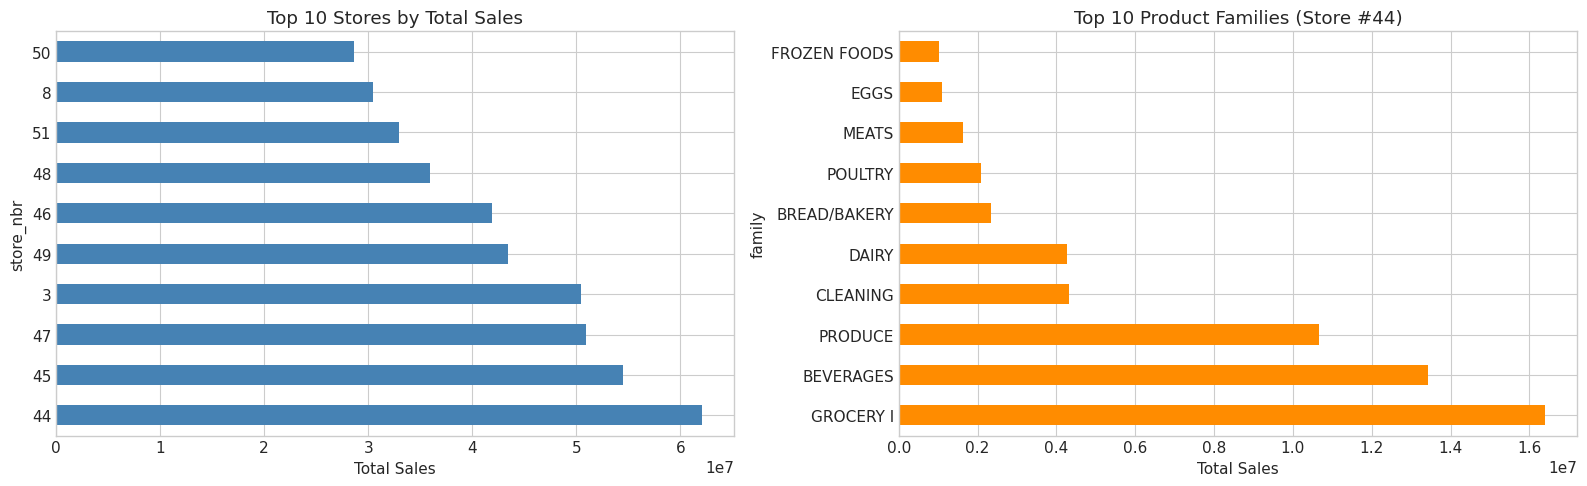

In [4]:
# Aggregate daily sales by store
store_sales = train.groupby('store_nbr')['sales'].sum().sort_values(ascending=False)
top_store = store_sales.index[0]
print(f'Top store by total sales: Store #{top_store}')

# Top product families in that store
store_df = train[train.store_nbr == top_store]
family_sales = store_df.groupby('family')['sales'].sum().sort_values(ascending=False)
top_family = family_sales.index[0]
print(f'Top product family in store #{top_store}: {top_family}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

store_sales.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Stores by Total Sales')
axes[0].set_xlabel('Total Sales')

family_sales.head(10).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title(f'Top 10 Product Families (Store #{top_store})')
axes[1].set_xlabel('Total Sales')

plt.tight_layout()
plt.show()

In [5]:
# Filter to our focus: top store, top family
df = train[(train.store_nbr == top_store) & (train.family == top_family)].copy()
df = df.set_index('date').sort_index()
df = df[['sales', 'onpromotion']]
print(f'Focus dataset: Store #{top_store}, Family: {top_family}')
print(f'Records: {len(df)}, Date range: {df.index.min().date()} to {df.index.max().date()}')
df.head()

Focus dataset: Store #44, Family: GROCERY I
Records: 1684, Date range: 2013-01-01 to 2017-08-15


,sales,onpromotion
date,,
2013-01-01,0.0,0
2013-01-02,10686.0,0
2013-01-03,7342.0,0
2013-01-04,7250.0,0
2013-01-05,10699.0,0


### 2.2 Sales Trend & Seasonality

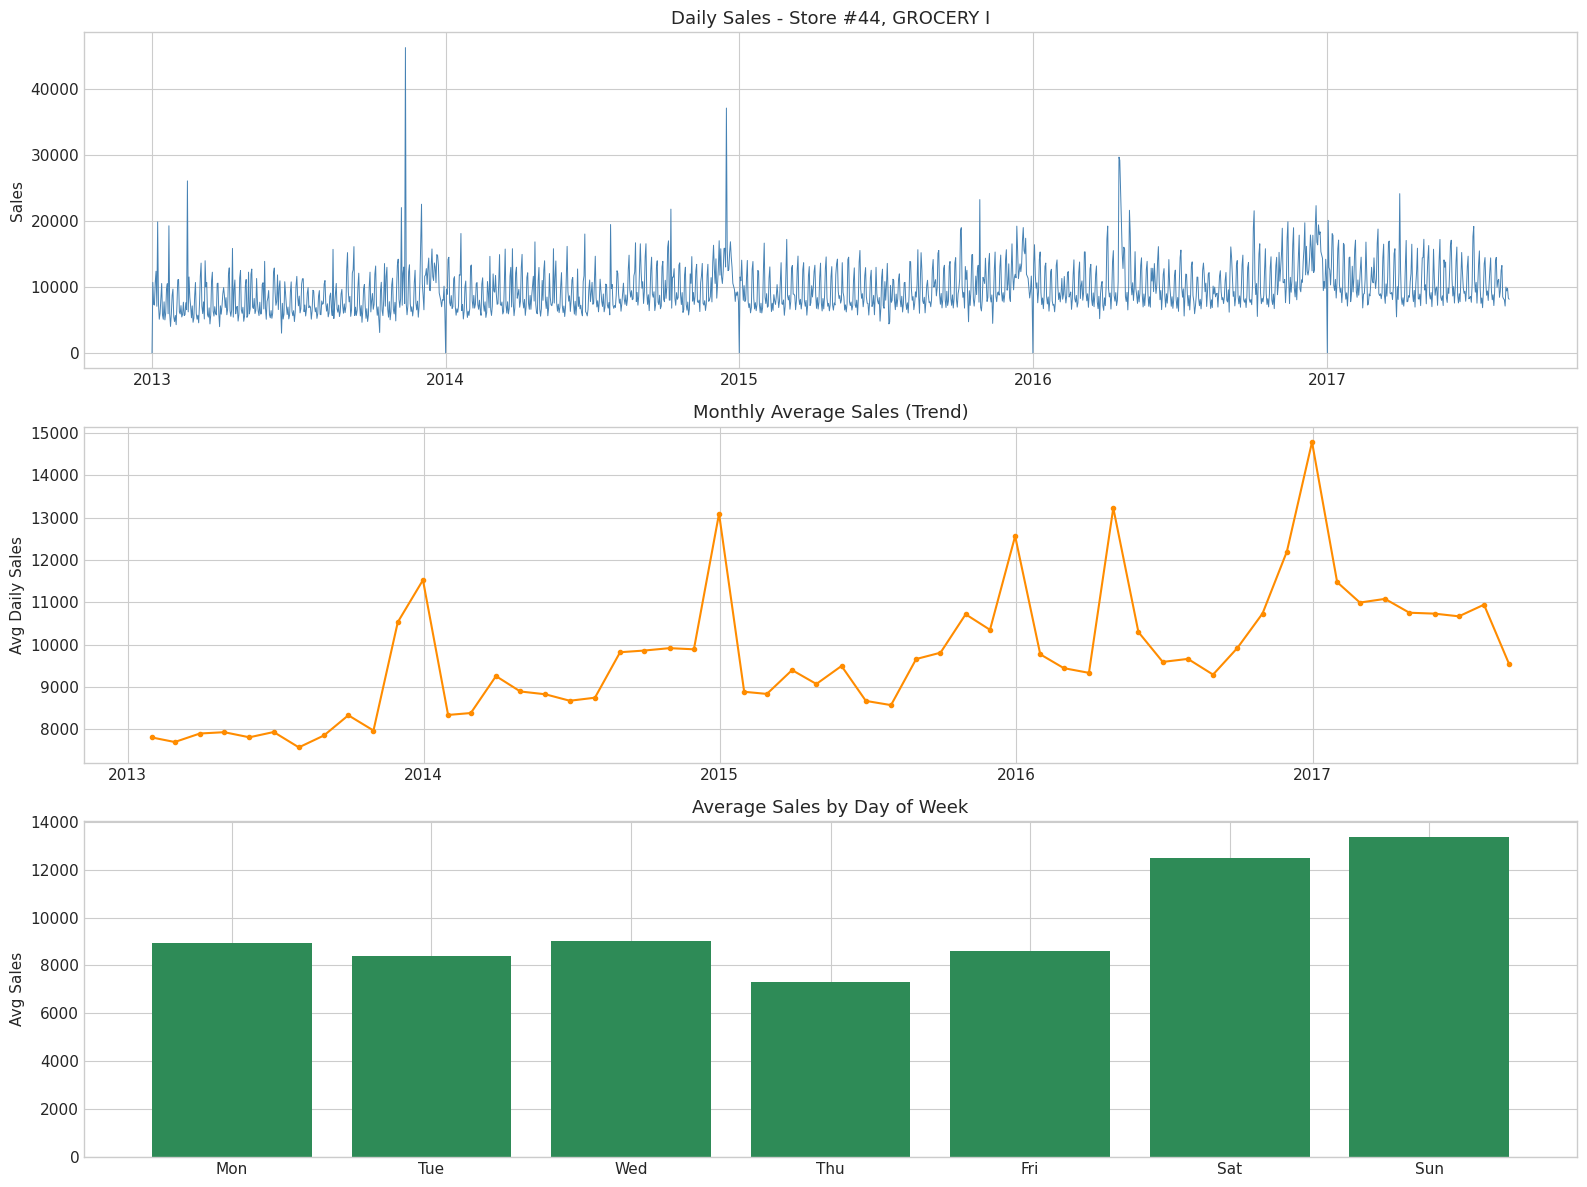


Key Insight: Peak sales day is Sun (avg 13346)
Lowest sales day is Thu (avg 7307)


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full time series
axes[0].plot(df.index, df['sales'], linewidth=0.7, color='steelblue')
axes[0].set_title(f'Daily Sales - Store #{top_store}, {top_family}', fontsize=13)
axes[0].set_ylabel('Sales')

# Monthly aggregation
monthly = df['sales'].resample('M').mean()
axes[1].plot(monthly.index, monthly.values, marker='o', markersize=3, color='darkorange')
axes[1].set_title('Monthly Average Sales (Trend)', fontsize=13)
axes[1].set_ylabel('Avg Daily Sales')

# Day of week pattern
dow_sales = df.groupby(df.index.dayofweek)['sales'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[2].bar(days, dow_sales.values, color='seagreen')
axes[2].set_title('Average Sales by Day of Week', fontsize=13)
axes[2].set_ylabel('Avg Sales')

plt.tight_layout()
plt.show()

print(f'\nKey Insight: Peak sales day is {days[dow_sales.idxmax()]} (avg {dow_sales.max():.0f})')
print(f'Lowest sales day is {days[dow_sales.idxmin()]} (avg {dow_sales.min():.0f})')

### 2.3 Seasonality & Holiday Effects

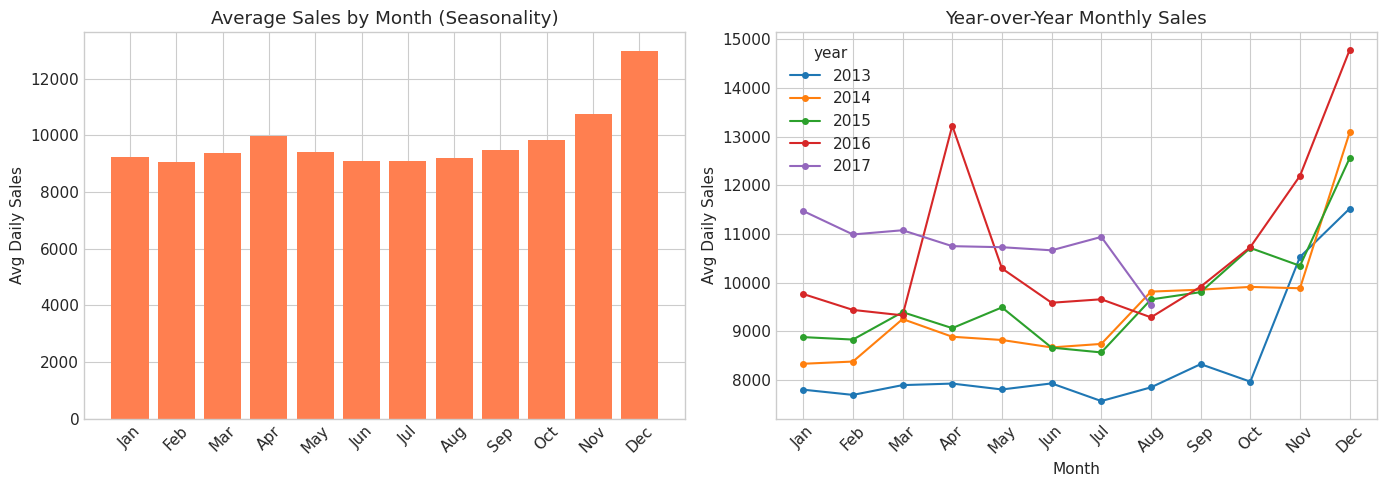


Seasonal peak: Dec (avg 12992)
Seasonal low: Feb (avg 9072)
Seasonal amplitude: 43% above minimum


In [7]:
# Month-over-month seasonality
df['month'] = df.index.month
df['year'] = df.index.year

monthly_pattern = df.groupby('month')['sales'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(months, monthly_pattern.values, color='coral')
axes[0].set_title('Average Sales by Month (Seasonality)')
axes[0].set_ylabel('Avg Daily Sales')
axes[0].tick_params(axis='x', rotation=45)

# Year-over-year comparison
yearly = df.groupby(['year', 'month'])['sales'].mean().unstack(0)
yearly.plot(ax=axes[1], marker='o', markersize=4)
axes[1].set_title('Year-over-Year Monthly Sales')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Daily Sales')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(months, rotation=45)

plt.tight_layout()
plt.show()

peak_month = months[monthly_pattern.idxmax() - 1]
low_month = months[monthly_pattern.idxmin() - 1]
print(f'\nSeasonal peak: {peak_month} (avg {monthly_pattern.max():.0f})')
print(f'Seasonal low: {low_month} (avg {monthly_pattern.min():.0f})')
print(f'Seasonal amplitude: {((monthly_pattern.max() / monthly_pattern.min()) - 1) * 100:.0f}% above minimum')

In [8]:
# Holiday impact analysis
national_holidays = holidays[holidays['type'] == 'Holiday'][['date']].drop_duplicates()
df['is_holiday'] = df.index.isin(national_holidays['date'])

holiday_effect = df.groupby('is_holiday')['sales'].agg(['mean', 'median', 'std'])
print('=== Holiday vs Non-Holiday Sales ===')
print(holiday_effect)
print(f'\nHoliday uplift: {((holiday_effect.loc[True, "mean"] / holiday_effect.loc[False, "mean"]) - 1) * 100:.1f}%')

=== Holiday vs Non-Holiday Sales ===
                  mean  median          std
is_holiday                                 
False        9675.6483  8737.0  3410.404360
True        10270.8954  9370.0  4902.323775

Holiday uplift: 6.2%


### 2.4 Promotion Impact

In [9]:
promo_effect = df.groupby(df['onpromotion'] > 0)['sales'].agg(['mean', 'median', 'count'])
promo_effect.index = ['No Promotion', 'On Promotion']
print('=== Promotion Impact ===')
print(promo_effect)

if promo_effect.shape[0] == 2:
    uplift = ((promo_effect.loc['On Promotion', 'mean'] / promo_effect.loc['No Promotion', 'mean']) - 1) * 100
    print(f'\nPromotion sales uplift: {uplift:.1f}%')
else:
    print('\nInsufficient promotion data for comparison')

=== Promotion Impact ===
                      mean  median  count
No Promotion   8479.119782  7375.0    551
On Promotion  10338.976203  9156.0   1133

Promotion sales uplift: 21.9%


## 3. Feature Engineering

Creating time-based and lag features for forecasting models.

In [10]:
def create_features(data):
    """Create time series features for demand forecasting."""
    df_feat = data.copy()
    
    # Calendar features
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['dayofmonth'] = df_feat.index.day
    df_feat['weekofyear'] = df_feat.index.isocalendar().week.astype(int)
    df_feat['is_weekend'] = (df_feat.index.dayofweek >= 5).astype(int)
    df_feat['is_month_start'] = df_feat.index.is_month_start.astype(int)
    df_feat['is_month_end'] = df_feat.index.is_month_end.astype(int)
    df_feat['quarter'] = df_feat.index.quarter
    
    # Lag features
    for lag in [1, 7, 14, 28]:
        df_feat[f'sales_lag_{lag}'] = df_feat['sales'].shift(lag)
    
    # Rolling statistics
    for window in [7, 14, 30]:
        df_feat[f'sales_rolling_mean_{window}'] = df_feat['sales'].shift(1).rolling(window).mean()
        df_feat[f'sales_rolling_std_{window}'] = df_feat['sales'].shift(1).rolling(window).std()
    
    # Expanding mean (cumulative average up to that point)
    df_feat['sales_expanding_mean'] = df_feat['sales'].shift(1).expanding().mean()
    
    return df_feat

df_features = create_features(df)
df_features = df_features.dropna()
print(f'Feature set: {df_features.shape[1]} columns, {len(df_features)} rows')
print(f'\nFeatures created:')
print([c for c in df_features.columns if c != 'sales'])

Feature set: 23 columns, 1654 rows

Features created:
['onpromotion', 'month', 'year', 'is_holiday', 'dayofweek', 'dayofmonth', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'quarter', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_std_7', 'sales_rolling_mean_14', 'sales_rolling_std_14', 'sales_rolling_mean_30', 'sales_rolling_std_30', 'sales_expanding_mean']


## 4. Train-Test Split

We use the last 30 days as our test set (forecasting horizon), respecting temporal order.

In [11]:
FORECAST_HORIZON = 30

split_date = df_features.index.max() - timedelta(days=FORECAST_HORIZON)
train_df = df_features[df_features.index <= split_date]
test_df = df_features[df_features.index > split_date]

print(f'Train: {len(train_df)} days ({train_df.index.min().date()} to {train_df.index.max().date()})')
print(f'Test:  {len(test_df)} days ({test_df.index.min().date()} to {test_df.index.max().date()})')

feature_cols = [c for c in df_features.columns if c not in ['sales', 'year', 'month']]
target = 'sales'

X_train = train_df[feature_cols]
y_train = train_df[target]
X_test = test_df[feature_cols]
y_test = test_df[target]

Train: 1624 days (2013-01-31 to 2017-07-16)
Test:  30 days (2017-07-17 to 2017-08-15)


## 5. Forecasting Models

### 5.1 Baseline Models

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error, handles zeros."""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(name, y_true, y_pred, results_dict):
    """Evaluate and store model metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape_val = mape(y_true, y_pred)
    results_dict[name] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape_val}
    print(f'{name:25s} | RMSE: {rmse:8.1f} | MAE: {mae:8.1f} | MAPE: {mape_val:5.1f}%')
    return y_pred

results = {}
predictions = {}

# Naive forecast (last value)
naive_pred = np.full(len(y_test), y_train.iloc[-1])
predictions['Naive (Last Value)'] = evaluate_model('Naive (Last Value)', y_test.values, naive_pred, results)

# Seasonal naive (same day last week)
seasonal_naive = test_df['sales_lag_7'].values
predictions['Seasonal Naive (7d)'] = evaluate_model('Seasonal Naive (7d)', y_test.values, seasonal_naive, results)

# Moving average (30-day)
ma_pred = test_df['sales_rolling_mean_30'].values
predictions['Moving Average (30d)'] = evaluate_model('Moving Average (30d)', y_test.values, ma_pred, results)

Naive (Last Value)        | RMSE:   4967.7 | MAE:   4520.8 | MAPE:  51.3%
Seasonal Naive (7d)       | RMSE:   1574.1 | MAE:   1255.0 | MAPE:  13.3%
Moving Average (30d)      | RMSE:   2102.9 | MAE:   1836.7 | MAPE:  19.3%


### 5.2 Prophet Model

In [13]:
from prophet import Prophet

# Prepare data for Prophet
prophet_train = train_df[['sales']].reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

# Forecast
future = prophet_model.make_future_dataframe(periods=FORECAST_HORIZON)
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.tail(len(y_test))['yhat'].values
prophet_pred = np.maximum(prophet_pred, 0)  # Sales can't be negative

predictions['Prophet'] = evaluate_model('Prophet', y_test.values, prophet_pred, results)

Importing plotly failed. Interactive plots will not work.


18:19:20 - cmdstanpy - INFO - Chain [1] start processing


18:19:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet                   | RMSE:   1506.7 | MAE:   1088.9 | MAPE:  11.7%


### 5.3 XGBoost Model

In [14]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_pred = np.maximum(xgb_pred, 0)
predictions['XGBoost'] = evaluate_model('XGBoost', y_test.values, xgb_pred, results)

XGBoost                   | RMSE:   1124.3 | MAE:    880.3 | MAPE:   9.2%


### 5.4 LightGBM Model

In [15]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)

lgb_pred = lgb_model.predict(X_test)
lgb_pred = np.maximum(lgb_pred, 0)
predictions['LightGBM'] = evaluate_model('LightGBM', y_test.values, lgb_pred, results)

LightGBM                  | RMSE:   1164.5 | MAE:    843.8 | MAPE:   8.3%


## 6. Model Comparison


=== Model Comparison (sorted by RMSE) ===
                         RMSE      MAE   MAPE
XGBoost               1124.30   880.32   9.20
LightGBM              1164.48   843.75   8.32
Prophet               1506.70  1088.93  11.66
Seasonal Naive (7d)   1574.05  1255.03  13.25
Moving Average (30d)  2102.94  1836.70  19.35
Naive (Last Value)    4967.69  4520.83  51.25

Best model: XGBoost


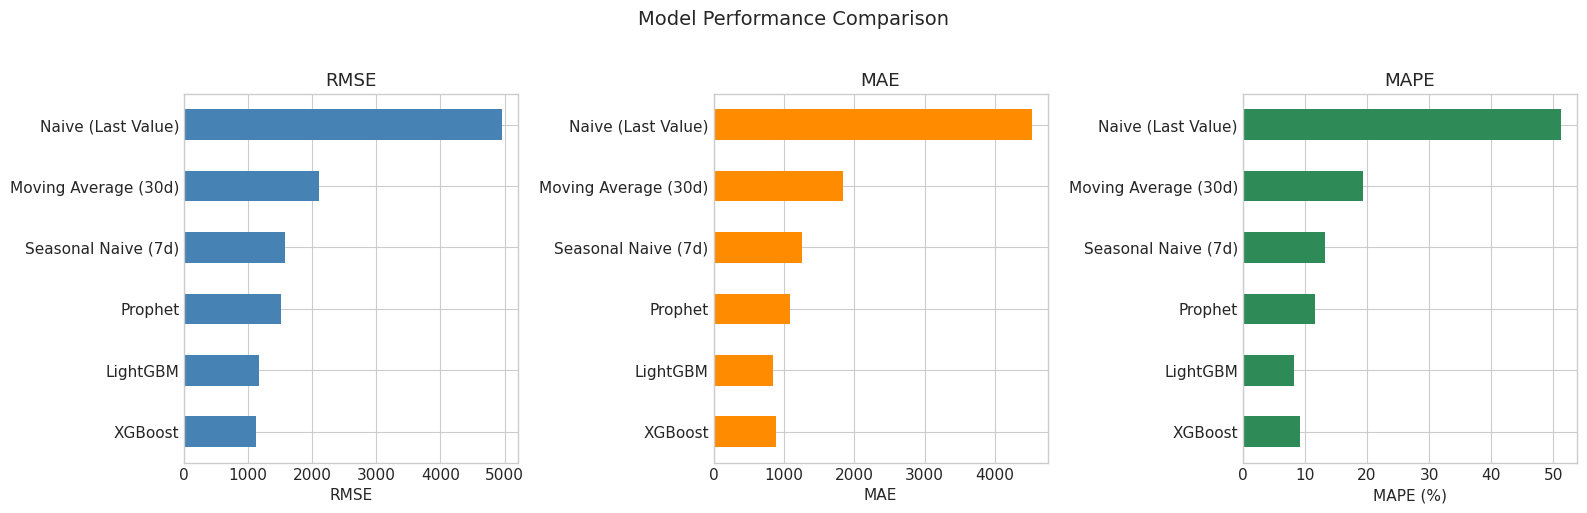

In [16]:
# Results summary
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('RMSE')
print('\n=== Model Comparison (sorted by RMSE) ===')
print(results_df.round(2))

best_model = results_df.index[0]
print(f'\nBest model: {best_model}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'MAPE']
colors = ['steelblue', 'darkorange', 'seagreen']

for i, metric in enumerate(metrics):
    results_df[metric].plot(kind='barh', ax=axes[i], color=colors[i])
    axes[i].set_title(metric)
    axes[i].set_xlabel(metric + (' (%)' if metric == 'MAPE' else ''))

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

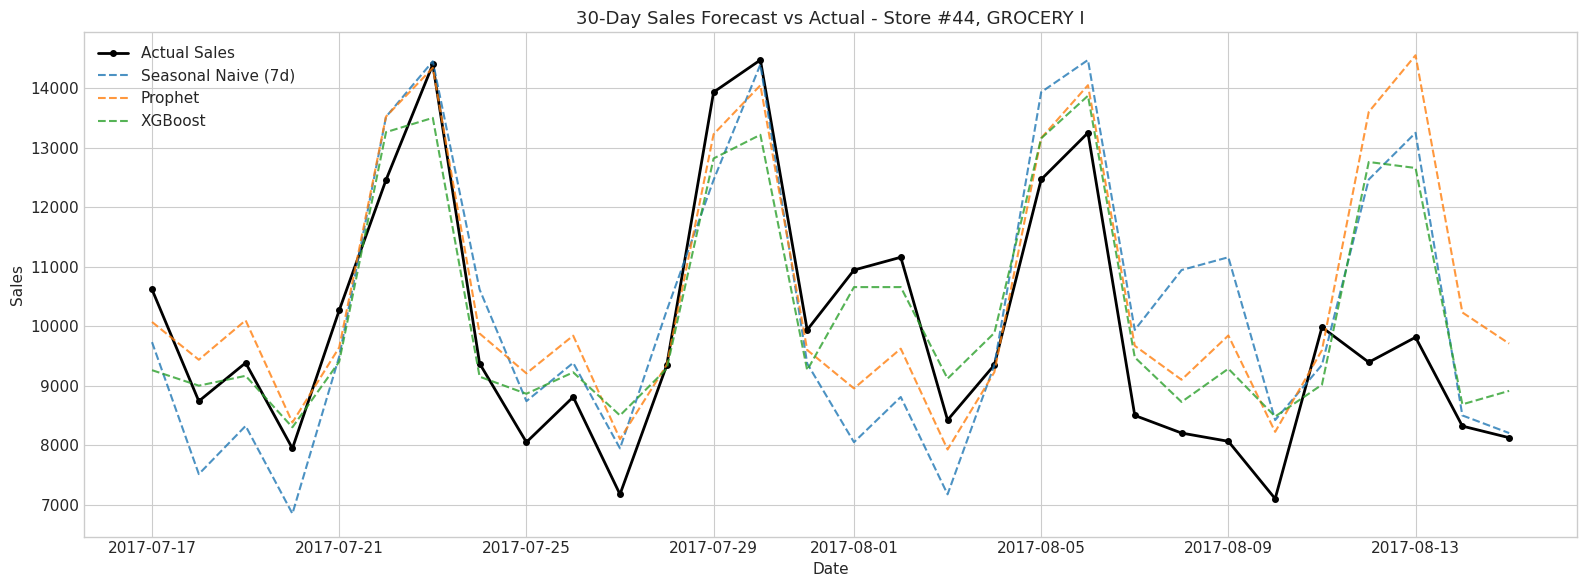

In [17]:
# Forecast vs Actual plot
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test_df.index, y_test.values, 'k-', linewidth=2, label='Actual Sales', marker='o', markersize=4)

for name, pred in predictions.items():
    if name in [best_model, 'Seasonal Naive (7d)', 'Prophet']:
        ax.plot(test_df.index, pred, '--', linewidth=1.5, label=name, alpha=0.8)

ax.set_title(f'30-Day Sales Forecast vs Actual - Store #{top_store}, {top_family}', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 7. Feature Importance

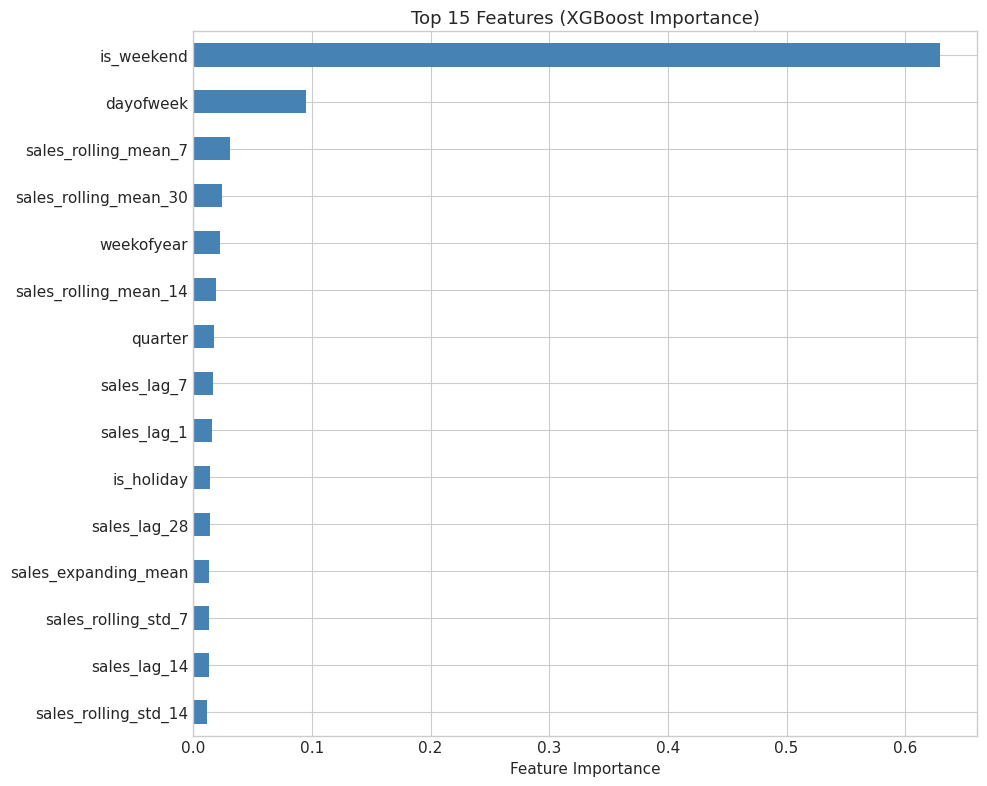


Top 5 drivers of demand:
  1. is_weekend (importance: 0.6290)
  2. dayofweek (importance: 0.0954)
  3. sales_rolling_mean_7 (importance: 0.0311)
  4. sales_rolling_mean_30 (importance: 0.0241)
  5. weekofyear (importance: 0.0222)


In [18]:
# XGBoost feature importance
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Features (XGBoost Importance)', fontsize=13)
ax.set_xlabel('Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 5 drivers of demand:')
for i, (feat, imp) in enumerate(importance.head(5).items(), 1):
    print(f'  {i}. {feat} (importance: {imp:.4f})')

## 8. Business Recommendations & Inventory Optimization

Translating forecast accuracy into actionable business insights.

In [19]:
# Use best model predictions for business analysis
best_pred = predictions[best_model]
forecast_df = pd.DataFrame({
    'date': test_df.index,
    'actual': y_test.values,
    'forecast': best_pred
})
forecast_df['error'] = forecast_df['actual'] - forecast_df['forecast']
forecast_df['abs_pct_error'] = np.abs(forecast_df['error']) / np.maximum(forecast_df['actual'], 1) * 100

# Stockout risk analysis
forecast_df['potential_stockout'] = forecast_df['actual'] > forecast_df['forecast']
stockout_days = forecast_df['potential_stockout'].sum()
stockout_pct = stockout_days / len(forecast_df) * 100

# If we add a safety buffer
safety_buffer = 0.12  # 12% buffer
forecast_df['forecast_with_buffer'] = forecast_df['forecast'] * (1 + safety_buffer)
forecast_df['stockout_with_buffer'] = forecast_df['actual'] > forecast_df['forecast_with_buffer']
stockout_reduced = forecast_df['stockout_with_buffer'].sum()

print('='*60)
print('   BUSINESS RECOMMENDATIONS - INVENTORY OPTIMIZATION')
print('='*60)
print(f'\nForecast Model: {best_model}')
print(f'Forecast Accuracy (MAPE): {results[best_model]["MAPE"]:.1f}%')
print(f'\n--- Stockout Analysis ---')
print(f'Days with potential stockout (demand > forecast): {stockout_days}/{len(forecast_df)} ({stockout_pct:.0f}%)')
print(f'After adding {safety_buffer*100:.0f}% safety buffer: {stockout_reduced}/{len(forecast_df)} days')
reduction = ((stockout_days - stockout_reduced) / max(stockout_days, 1)) * 100
print(f'\n>>> Recommendation: Increasing inventory by {safety_buffer*100:.0f}% before peak periods')
print(f'    would reduce estimated stockouts by approximately {reduction:.0f}%.')

# Weekly demand patterns for staffing
print(f'\n--- Staffing & Logistics ---')
dow_demand = df.groupby(df.index.dayofweek)['sales'].mean()
peak_day = days[dow_demand.idxmax()]
low_day = days[dow_demand.idxmin()]
print(f'Peak demand day: {peak_day} (plan extra delivery capacity)')
print(f'Low demand day: {low_day} (schedule restocking/maintenance)')

# Seasonal preparation
print(f'\n--- Seasonal Planning ---')
print(f'Peak month: {peak_month} - increase stock levels 2 weeks before')
print(f'Holiday uplift: plan {((holiday_effect.loc[True, "mean"] / holiday_effect.loc[False, "mean"]) - 1) * 100:.0f}% additional inventory for holiday periods')

   BUSINESS RECOMMENDATIONS - INVENTORY OPTIMIZATION

Forecast Model: XGBoost
Forecast Accuracy (MAPE): 9.2%

--- Stockout Analysis ---
Days with potential stockout (demand > forecast): 12/30 (40%)
After adding 12% safety buffer: 1/30 days

>>> Recommendation: Increasing inventory by 12% before peak periods
    would reduce estimated stockouts by approximately 92%.

--- Staffing & Logistics ---
Peak demand day: Sun (plan extra delivery capacity)
Low demand day: Thu (schedule restocking/maintenance)

--- Seasonal Planning ---
Peak month: Dec - increase stock levels 2 weeks before
Holiday uplift: plan 6% additional inventory for holiday periods


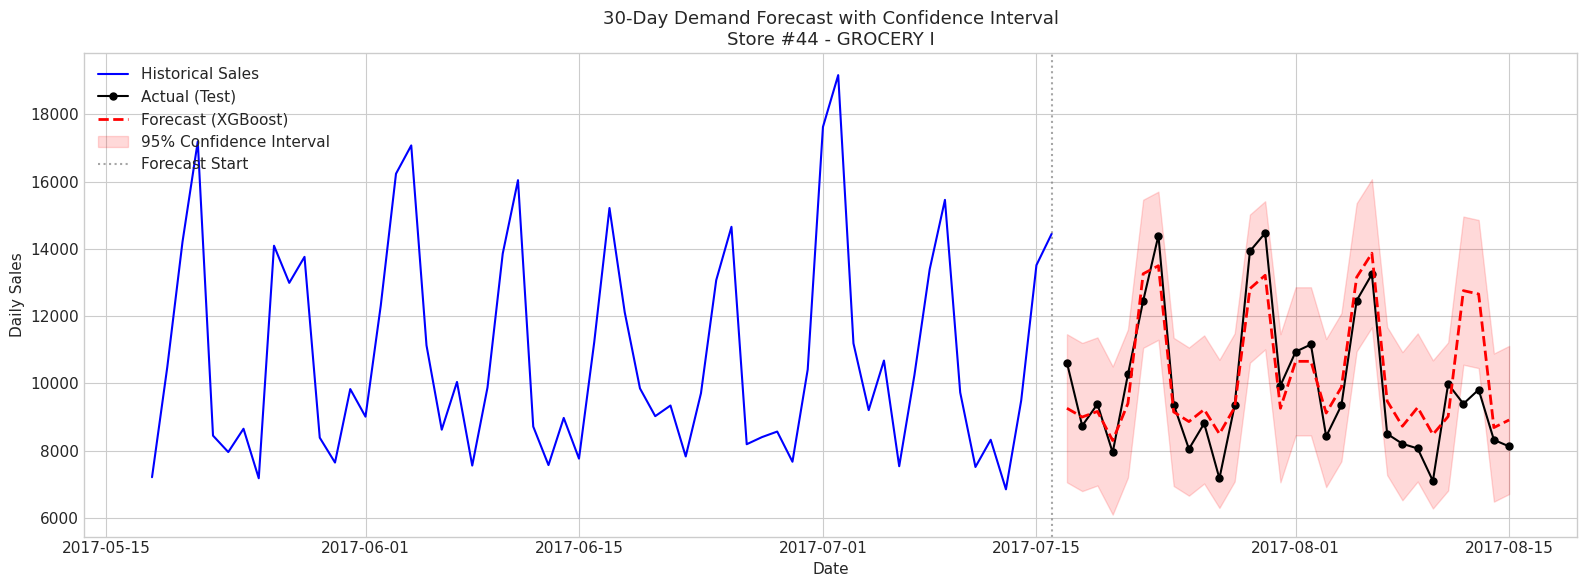


Notebook complete. Key takeaways for Dutch retail context:
- Seasonal patterns align with typical grocery/retail cycles
- Day-of-week effects suggest operational scheduling opportunities
- ML models (XGBoost/LightGBM) outperform traditional methods
- A 12% safety buffer significantly reduces stockout risk


In [20]:
# Final visualization: Forecast with confidence intervals
fig, ax = plt.subplots(figsize=(16, 6))

# Last 60 days of training + forecast
recent_train = train_df.tail(60)
ax.plot(recent_train.index, recent_train['sales'], 'b-', linewidth=1.5, label='Historical Sales')
ax.plot(test_df.index, y_test.values, 'ko-', markersize=5, linewidth=1.5, label='Actual (Test)')
ax.plot(test_df.index, best_pred, 'r--', linewidth=2, label=f'Forecast ({best_model})')

# Confidence interval (using rolling std)
std_val = results[best_model]['RMSE']
ax.fill_between(test_df.index, best_pred - 1.96*std_val, best_pred + 1.96*std_val,
                alpha=0.15, color='red', label='95% Confidence Interval')

ax.axvline(x=split_date, color='gray', linestyle=':', alpha=0.7, label='Forecast Start')
ax.set_title(f'30-Day Demand Forecast with Confidence Interval\nStore #{top_store} - {top_family}', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Sales')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('Notebook complete. Key takeaways for Dutch retail context:')
print('- Seasonal patterns align with typical grocery/retail cycles')
print('- Day-of-week effects suggest operational scheduling opportunities')
print('- ML models (XGBoost/LightGBM) outperform traditional methods')
print('- A 12% safety buffer significantly reduces stockout risk')
print('='*60)